## 22.1 MobileNet — Complete Revision Notes

---

# 1. 🎯 Why MobileNet?

Traditional CNNs can be computationally expensive.

For mobile/edge devices, important constraints include:

* Limited compute
* Limited memory
* Limited battery/power
* Latency requirements
* Limited hardware resources

MobileNet was designed around efficient CNN computation for **mobile and embedded vision**.

Its original design uses:

1. **Depthwise-separable convolution**
2. **Width multiplier \(\alpha\)**
3. **Resolution multiplier \(\rho\)**

---

# 2. 🔥 Core Idea

A standard convolution performs two types of operations together:

```text
STANDARD CONVOLUTION

Spatial filtering
       +
Channel mixing
       ↓
    Output
```

MobileNet separates them:

```text
INPUT
  │
  ▼
Depthwise Convolution
  │
  │ Spatial filtering
  ▼
Pointwise Convolution
  │
  │ Channel mixing
  ▼
OUTPUT
```

Therefore:

$$
\boxed{
\text{Depthwise-Separable Conv}
=
\text{Depthwise Conv}
+
\text{Pointwise Conv}
}
$$

This decomposition is the fundamental computational idea of the original MobileNet.

---

# 3. 🧠 Standard Convolution

For:

* Kernel = \(K\times K\)
* Input channels = \(M\)
* Output channels = \(N\)
* Feature-map size = \(D_F\times D_F\)

Parameter count:

$$
\boxed{
K^2MN
}
$$

Approximate multiplication count:

$$
\boxed{
K^2MND_F^2
}
$$

Why expensive?

Because every output channel uses:

* all input channels
* across the entire spatial kernel.

---

# 4. 🔥 Depthwise Convolution

Depthwise convolution applies **one spatial filter independently to each input channel**.

Example:

```text
C1 ──→ 3×3 filter ──→ D1
C2 ──→ 3×3 filter ──→ D2
C3 ──→ 3×3 filter ──→ D3
...
C64 ─→ 3×3 filter ──→ D64
```

There is no channel mixing at this stage.

For \(M\) input channels:

$$
\boxed{
Parameters=K^2M
}
$$

Approximate computation:

$$
\boxed{
K^2MD_F^2
}
$$

---

# 5. 🧠 Pointwise Convolution

Pointwise convolution is simply:

$$
\boxed{1\times1\text{ convolution}}
$$

It performs channel mixing.

Suppose:

```text
Input channels = 64
Output channels = 128
```

Then:

$$
64\rightarrow128
$$

The \(1\times1\) kernel looks at all channels at one spatial location.

Mathematically:

$$
y=Wx+b
$$

where:

$$
W\in\mathbb{R}^{128\times64}
$$

Therefore:

$$
\boxed{
Parameters=MN
}
$$

---

# 6. 🔥 Depthwise + Pointwise

For a MobileNet block:

```text
Input
  ↓
Depthwise 3×3
  ↓
Pointwise 1×1
  ↓
Output
```

Cost:

### Depthwise

$$
K^2M
$$

### Pointwise

$$
MN
$$

Total:

$$
\boxed{
K^2M+MN
}
$$

Compared with standard convolution:

$$
\boxed{
K^2MN
}
$$

This is the mathematical reason for the efficiency improvement.

---

# 7. 🔢 Numerical Example

Given:

```text
Input channels = 64
Output channels = 128
Kernel = 3×3
```

## Standard convolution

$$
3^2\times64\times128
$$

$$
=\boxed{73,728}
$$

parameters.

## Depthwise

$$
3^2\times64
=
\boxed{576}
$$

## Pointwise

$$
1^2\times64\times128
=
\boxed{8,192}
$$

## Combined

$$
576+8192
=
\boxed{8,768}
$$

Therefore:

```text
Standard Conv       73,728
Depthwise-Separable  8,768
```

Approximately:

$$
\boxed{8.4\times}
$$

fewer parameters for this example.

---

# 8. 🧠 Why Does It Work?

Think of the two operations as two separate questions.

### Depthwise convolution asks:

> **What spatial pattern exists within each channel?**

Examples:

* edges
* textures
* local patterns

### Pointwise convolution asks:

> **How should information from different channels be combined?**

Therefore:

$$
\boxed{
\text{Depthwise = spatial filtering}
}
$$

$$
\boxed{
\text{Pointwise = channel mixing}
}
$$

---

# 9. 🔢 Tensor-Shape Flow

Example:

```text
Input
[1, 64, 32, 32]

       ↓

Depthwise 3×3
[1, 64, 32, 32]

       ↓

Pointwise 1×1
[1, 128, 32, 32]

       ↓

Output
[1, 128, 32, 32]
```

Important:

### Depthwise

$$
64\rightarrow64
$$

### Pointwise

$$
64\rightarrow128
$$

The pointwise layer changes the channel count.

---

# 10. 🔥 PyTorch Implementation

A depthwise convolution can be implemented with:

```python
nn.Conv2d(
    in_channels=C,
    out_channels=C,
    kernel_size=3,
    padding=1,
    groups=C
)
```

The key:

```python
groups=C
```

When:

$$
groups=in\_channels
$$

the convolution is in the depthwise configuration, subject to the channel constraints documented by PyTorch.

Official PyTorch documentation:
[https://docs.pytorch.org/docs/main/generated/torch.nn.Conv2d.html](https://docs.pytorch.org/docs/main/generated/torch.nn.Conv2d.html)

---

# 11. 🧠 Why `groups=C`?

Normal convolution:

```text
groups = 1

C1 ─┐
C2 ─┤
C3 ─┼──→ outputs
... │
C64─┘
```

Every output can access every input channel.

Depthwise:

```text
groups = 64

C1  ───→ D1
C2  ───→ D2
C3  ───→ D3
...
C64 ───→ D64
```

Each group contains one input channel.

Therefore the depthwise weight tensor has the structure:

$$
[C,1,K,K]
$$

for the standard depthwise case.

---

# 12. 💻 Complete Depthwise-Separable Block

```python
class DepthwiseSeparableConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=1,
            groups=in_channels
        )

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x
```

Conceptually:

```text
Input
 ↓
DW Conv
 ↓
PW Conv
 ↓
Output
```

---

# 13. 🏗️ MobileNet-Style Block

A simplified MobileNet block can be represented as:

```text
Input
  │
  ▼
Depthwise 3×3
  │
  ▼
BatchNorm
  │
  ▼
ReLU
  │
  ▼
Pointwise 1×1
  │
  ▼
BatchNorm
  │
  ▼
ReLU
  │
  ▼
Output
```

The exact architecture varies across MobileNet generations.

---

# 14. 📱 Width Multiplier — \(\alpha\)

The width multiplier controls the number of channels.

If:

$$
\alpha=1
$$

the original width is retained.

If:

$$
\alpha=0.5
$$

approximately half the channels are used.

Example:

```text
Original:

64 → 128 → 256

α = 0.5:

32 → 64 → 128
```

Therefore:

$$
\boxed{
\alpha\rightarrow\text{number of channels}
}
$$

---

# 15. 🔢 Width Scaling

For pointwise convolution:

$$
MN
$$

After width scaling:

$$
(\alpha M)(\alpha N)
$$

Therefore:

$$
\boxed{
\alpha^2MN
}
$$

So pointwise computation scales approximately with:

$$
\boxed{\alpha^2}
$$

The depthwise component scales approximately with:

$$
\boxed{\alpha}
$$

because:

$$
K^2M
\rightarrow
K^2(\alpha M)
$$

---

# 16. 🧠 Width Multiplier Trade-off

```text
α ↓
 │
 ├── fewer channels
 ├── fewer parameters
 ├── lower computation
 ├── lower memory
 └── potentially lower representational capacity
```

Therefore:

$$
\boxed{
\text{Efficiency} \leftrightarrow \text{Model Capacity}
}
$$

There is no universally optimal \(\alpha\).

The choice depends on the task and deployment constraints.

---

# 17. 📐 Resolution Multiplier — \(\rho\)

The resolution multiplier controls spatial resolution.

Example:

$$
224\times224
$$

with:

$$
\rho=0.5
$$

becomes approximately:

$$
112\times112
$$

Therefore:

$$
\boxed{
\rho\rightarrow\text{spatial resolution}
}
$$

---

# 18. 🔢 Why Resolution Has a Quadratic Effect

Original:

$$
224^2=50,176
$$

Half resolution:

$$
112^2=12,544
$$

Ratio:

$$
\frac{12,544}{50,176}=0.25
$$

Therefore:

$$
\boxed{
\text{Spatial computation}\propto\rho^2
}
$$

Halving both height and width produces approximately one-quarter as many spatial positions.

---

# 19. 🧠 Width vs Resolution

|                      | Width \(\alpha\)                                | Resolution \(\rho\)         |
| -------------------- | ----------------------------------------------- | --------------------------- |
| Controls             | Channels                                        | Spatial dimensions          |
| Example              | 128 → 64                                        | 224×224 → 112×112           |
| Reduces              | Feature capacity                                | Spatial detail              |
| Main effect          | Channel computation                             | Number of spatial locations |
| Typical cost scaling | \(\alpha\), \(\alpha^2\) depending on operation | \(\rho^2\)                  |

Mental model:

```text
α → "How many features?"

ρ → "How much spatial detail?"
```

---

# 20. 🔥 Combined Scaling

MobileNet can use both:

$$
\alpha
$$

and:

$$
\rho
$$

Conceptually:

```text
                 MobileNet
                     │
          ┌──────────┴──────────┐
          │                     │
       Width α              Resolution ρ
          │                     │
          ▼                     ▼
   Fewer channels         Smaller maps
          │                     │
          └──────────┬──────────┘
                     ▼
             Lower computation
```

The original MobileNet formulation combines these scaling factors with its depthwise-separable convolution cost.

---

# 21. 🧮 Complete Cost Intuition

For a depthwise-separable convolution:

$$
C_{DS}
=
K^2M+MN
$$

After width scaling:

$$
C_{DS,\alpha}
=
\alpha K^2M+\alpha^2MN
$$

After spatial-resolution scaling:

$$
D_F\rightarrow\rho D_F
$$

so the spatial component scales approximately with:

$$
\rho^2
$$

The important intuition:

```text
α → changes CHANNEL dimensions

ρ → changes SPATIAL dimensions
```

---

# 22. ⚠️ FLOPs ≠ Actual Latency

A model having fewer FLOPs does **not** guarantee proportionally lower real-world latency.

Actual latency depends on:

* Hardware
* Memory access
* Kernel implementation
* Framework
* Accelerator
* Batch size
* Parallelism

Therefore:

$$
\boxed{
\text{FLOPs} \neq \text{Latency}
}
$$

FLOPs are a useful computational estimate, not a complete deployment-performance measurement.

---

# 23. 🏭 Industry Perspective

For an edge device, you may have:

```text
Accuracy
   ↑
   │
   │       Large CNN
   │
   │
   │   MobileNet
   │
   └──────────────────→
      Compute / Cost
```

The actual engineering problem is not simply:

> "Which model has maximum accuracy?"

Instead consider:

* Accuracy
* Latency
* Memory
* Power
* Model size
* Hardware
* Throughput
* Input resolution

The appropriate architecture depends on the deployment requirements.

---

# 24. ⚔️ Standard CNN vs MobileNet

| Property            | Standard Conv                  | MobileNet-style         |
| ------------------- | ------------------------------ | ----------------------- |
| Spatial filtering   | Yes                            | Depthwise               |
| Channel mixing      | Same operation                 | Pointwise               |
| Kernel              | e.g. 3×3×channels              | 3×3 depthwise + 1×1     |
| Parameters          | Higher                         | Lower                   |
| Computation         | Higher                         | Lower                   |
| Channel interaction | Jointly with spatial filtering | Separate                |
| Edge suitability    | Depends                        | Designed for efficiency |

---

# 25. 🧠 Most Important Formulas

### Standard convolution

$$
\boxed{K^2MN}
$$

parameters.

---

### Depthwise convolution

$$
\boxed{K^2M}
$$

parameters.

---

### Pointwise convolution

$$
\boxed{MN}
$$

parameters.

---

### Depthwise-separable convolution

$$
\boxed{K^2M+MN}
$$

parameters.

---

### Standard computation

$$
\boxed{K^2MND_F^2}
$$

---

### Width-scaled pointwise computation

$$
\boxed{\alpha^2MN}
$$

---

### Resolution-scaled spatial computation

$$
\boxed{\rho^2}
$$

relative to the original spatial computation.

---

# 26. 🚨 Common Mistakes

### ❌ "Depthwise convolution mixes channels."

No.

It processes channels independently.

---

### ❌ "Pointwise convolution looks at neighboring pixels."

No.

A \(1\times1\) convolution operates at one spatial location.

---

### ❌ "Depthwise convolution alone is MobileNet."

No.

The key operation is:

$$
\boxed{\text{Depthwise + Pointwise}}
$$

---

### ❌ "Width multiplier changes image resolution."

No.

$$
\alpha\rightarrow\text{channels}
$$

---

### ❌ "Resolution multiplier changes number of channels."

No.

$$
\rho\rightarrow\text{spatial resolution}
$$

---

### ❌ "Half resolution means half computation."

No.

If both dimensions are halved:

$$
0.5^2=0.25
$$

so spatial positions become approximately **25%** of the original.

---

### ❌ "Fewer FLOPs always means faster."

No.

Hardware and implementation matter.

---

# 27. 🎯 Interview Questions

### Q1. What is MobileNet?

A lightweight CNN architecture family designed for efficient vision, particularly mobile and embedded applications.

### Q2. What is the main idea behind MobileNet?

Depthwise-separable convolution.

### Q3. What does depthwise convolution do?

Performs spatial filtering independently for each input channel.

### Q4. What does pointwise convolution do?

Uses \(1\times1\) convolution to mix information across channels.

### Q5. Why is MobileNet computationally cheaper?

It factorizes standard convolution into much cheaper depthwise and pointwise operations.

### Q6. What is the width multiplier?

A factor \(\alpha\) controlling the number of channels.

### Q7. What is the resolution multiplier?

A factor \(\rho\) controlling spatial resolution.

### Q8. Why does reducing resolution save a lot of computation?

Because spatial computation depends on the number of spatial locations:

$$
H\times W
$$

and both dimensions are scaled.

### Q9. Why is `groups=in_channels` important in PyTorch?

It creates the depthwise grouping where each input channel is processed independently, subject to the channel constraints.

### Q10. Does fewer FLOPs guarantee lower latency?

No. Hardware and implementation characteristics also determine latency.

---

# 28. 💻 Important PyTorch Concepts

### Depthwise

```python
nn.Conv2d(
    C,
    C,
    kernel_size=3,
    padding=1,
    groups=C
)
```

### Pointwise

```python
nn.Conv2d(
    C_in,
    C_out,
    kernel_size=1
)
```

### Full depthwise-separable block

```python
depthwise → pointwise
```

In later MobileNet generations, the building block becomes more sophisticated.

Torchvision's current MobileNetV2 implementation, for example, uses **inverted residual blocks** and lightweight depthwise convolutions in an expanded intermediate representation. ([PyTorch][2])

---

# 🖼️ 29. Online Visual Resources

## 🔗 Original MobileNet Paper

**MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications**

[https://arxiv.org/abs/1704.04861](https://arxiv.org/abs/1704.04861)

Use this for:

* Original architecture
* Depthwise-separable convolution
* Width multiplier
* Resolution multiplier
* Computational equations
* Original experimental results

---

## 🔗 PyTorch Conv2d Documentation

**PyTorch `Conv2d`**

[https://docs.pytorch.org/docs/main/generated/torch.nn.Conv2d.html](https://docs.pytorch.org/docs/main/generated/torch.nn.Conv2d.html)

Especially useful for understanding:

```text
groups
stride
padding
channels
depthwise convolution
```

---

## 🔗 Torchvision MobileNetV2

**Official Torchvision MobileNetV2 documentation**

[https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v2.html](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v2.html)

Current Torchvision documents MobileNetV2 as an architecture based on **inverted residuals and linear bottlenecks** and provides pretrained weights and model metadata. ([PyTorch Docs][1])

---

## 🖼️ Architecture Visuals

![Image](https://images.openai.com/static-rsc-4/MMZOiTmX4XYde7jasFM8HK5KhEQkiGaLfZlruk0Xgk_-c1c2-Bm9DJyben7Xist_1zaHQ0F-yhzcLYnoGLPd2F9oeylX-A8q3KTYhfux4wMBe-xWHpAB0vtZjS78K56wB8bz3jw-3KCXEDeQfWJkKwxkBhUHSCYjVJ6qvcMO5VLlt0-WlZgYSpz8LJRFx8F9?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/0nVbXAX_MhrfW59rJcwvrq69A741qjS0B_iCjHFboazapcvORVvyZmNywqxxaffGmlRZgICTt7JS1l29aHSZ6nF1Q77vQ0iBwt1lYCoFF66iz1cFMOOrRZed7ggd18JQs2D3g2gvnjyz3Lu32fK-JG8nAcK91BodNeySFF3jXQHusmuW02I32hGSkDKXzayg?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/_BR_TTp2RWLbhFZJF6Gx0Q7Y__WizXVfMXNUe7g0bqI9iYnT-zNHrhNRhDFL0NW_JDbWyFB3LWxHXBsuyHc0k8HRVGLKrmjSTjOiiCXNLjY7DIS3Ll3_bEBCuqX0agklceiqHkBHaJt0sj0hRR7FyRi4nu7hTfFVaYXepCrZDX8_3f0WgJ440NDAq1Tc5v5v?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/0N0R9qqb3bX7_VA5BeQGZyFNhQD8xzM0ZKvqfP1xR_0cl9ekJXugBtX1M6m3dRYCvyX5kQwds2Xm6rRb_jg20MZXp2OxSSMjE8dA3125vdSsdjer_m2gel_98Go7B0gbrckOlBoovukHRCkbMOzSWMoWboWmVhLue33gV4gY1MXB9KdsrWLjy-CC5AnYrdHN?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/hGfTKUyTjJafk3751BFtL59fVVizZDGJgGctzAABPWXtTxIEnuxedEoO_aKsEr3RsZsvQWGCEDOCCEvxHG_PTLSOminkp6H8FO3GTS5wem7irCk4MSgtKg7lds9Le129lBar6S74FtfSQifrWPTfHVmTut3r92DHD92sgtC8MqJJeShVJzHrv8EQUigf3tEO?purpose=fullsize)

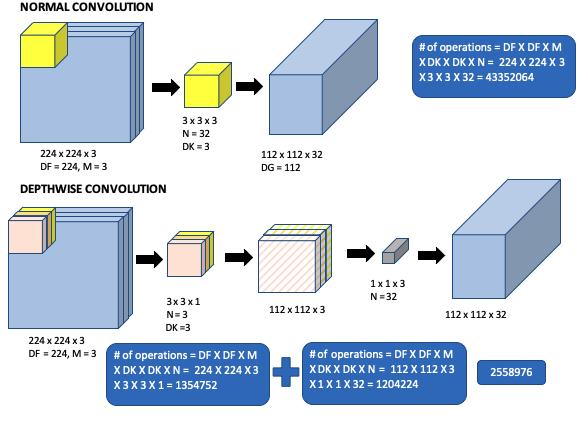

---

# 30. ⚡ Quick Revision Cheat Sheet

```text
MOBILENET
│
├── Goal
│   └── Efficient CNN for mobile/edge vision
│
├── Core operation
│   └── Depthwise-Separable Convolution
│
│       ├── Depthwise 3×3
│       │   └── Spatial filtering
│       │
│       └── Pointwise 1×1
│           └── Channel mixing
│
├── Width multiplier α
│   └── Controls number of channels
│
└── Resolution multiplier ρ
    └── Controls spatial resolution
```

### Core equations

$$
\boxed{
Standard = K^2MN
}
$$

$$
\boxed{
Depthwise = K^2M
}
$$

$$
\boxed{
Pointwise = MN
}
$$

$$
\boxed{
Separable = K^2M+MN
}
$$

### Remember:

```text
Depthwise → SPACE
Pointwise → CHANNELS

α → WIDTH / CHANNELS
ρ → RESOLUTION / SPATIAL SIZE
```

### One-line interview answer:

> **MobileNet reduces CNN computation by factorizing standard convolution into depthwise spatial filtering and pointwise channel mixing, while width and resolution multipliers allow additional control over model size and computation.**

### 🔥 Final takeaway

If you remember just this, you're good:

$$
\boxed{
\text{MobileNet}
=
\underbrace{\text{Depthwise + Pointwise}}_{\text{efficient convolution}}
+
\underbrace{\alpha}_{\text{width}}
+
\underbrace{\rho}_{\text{resolution}}
}
$$

---